# Prob 2: a 2-layer recurrent neural network

## (vectorized version)

In this exercise, we will build a recurrent neural network that computes the top-2 largest elements of an input sequence.

In [ ]:
pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 8.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 23.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 12.3 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torch.optim as optim
import numpy as np

np.random.seed(42)
torch.manual_seed(42)

dim_hidden = 6 # dimension of hidden state
dim_input = 1 # dimension of the input data
dim_output = 2 # dimension of output, corresponding to the largest and second largest entry, respectively

# model parameters
Wrec1 = torch.randn(dim_hidden, dim_hidden, requires_grad=True)
Win1 = torch.randn(dim_input, dim_hidden, requires_grad=True)

Wrec2 = torch.randn(dim_hidden, dim_hidden, requires_grad=True)
Win2 = torch.randn(dim_hidden, dim_hidden, requires_grad=True)
Wout = torch.randn(dim_hidden, dim_output, requires_grad=True)

## The "recurrent unit" basic building block

In [ ]:
def recurrent_unit(x, h_prev, Wrec, Win):
    """
    INPUT
    x - a (minibatch_size, dim_input) tensor
    h_prev - a tensor of shape (minibatch_size, dim_hidden)

    RETURN
    h_next - a tensor of shape (minibatch_size, dim_hidden)
    """

    h_next = torch.relu(torch.matmul(h_prev, Wrec) + x @ Win)
    return h_next

## The forward function

In [ ]:
def forward(seqs, Wrec1, Win1, Wrec2, Win2, Wout):
    """
    INPUT
    seqs: (minibatch_size, seq_length, dim_input)
    RETURN
    yhat: (minibatch_size, 2)
    """
    minibatch_size, seq_length, _ = seqs.shape

    # Initialize hidden states
    h1 = torch.zeros(minibatch_size, dim_hidden)
    h2 = torch.zeros(minibatch_size, dim_hidden)

    # Process each time step
    for t in range(seq_length):
        x_t = seqs[:, t, :]                     # (minibatch_size, dim_input)
        h1 = recurrent_unit(x_t, h1, Wrec1, Win1)
        h2 = recurrent_unit(h1, h2, Wrec2, Win2)

    # Output from last time step of layer 2
    yhat = h2 @ Wout
    return yhat



# The main training loop

In [ ]:
import pdb
learning_rate = 0.001
num_epochs = 100000
minibatch_size = 2**8

optimizer = optim.Adam([Wrec1, Win1, Wrec2,Win2, Wout], lr=learning_rate)

loss_history = []

seq_length = 8

for epoch in range(num_epochs):
    # randomly generated minibatch
    seqs = torch.tensor(np.random.randn(minibatch_size, seq_length, dim_input), dtype=torch.float32)

    # Ground truth: top-2 largest values in each sequence
    top2_seqs, _ = torch.topk(seqs.squeeze(-1), 2, dim=1)  # shape (minibatch, 2)

    # Forward pass through 2-layer RNN
    yhat = forward(seqs, Wrec1, Win1, Wrec2, Win2, Wout)

    # MSE loss between prediction and true top-2 values
    loss = torch.mean((yhat - top2_seqs) ** 2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 10000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")


# expected output
#
# Epoch 0, Loss: 88.92538452148438
# Epoch 10000, Loss: 0.1389428973197937
# Epoch 20000, Loss: 0.016868984326720238
# ...

Epoch 0, Loss: 27202.771484375
Epoch 10000, Loss: 0.24047702550888062
Epoch 20000, Loss: 0.06485043466091156
Epoch 30000, Loss: 0.004975503776222467
Epoch 40000, Loss: 0.002012070268392563
Epoch 50000, Loss: 0.0042727249674499035
Epoch 60000, Loss: 0.0017443331889808178
Epoch 70000, Loss: 0.0011913113994523883
Epoch 80000, Loss: 0.0004905146197415888
Epoch 90000, Loss: 0.0002780475770123303


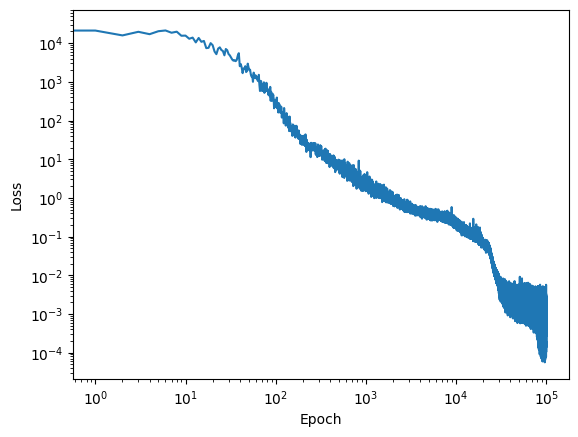

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
seq_length = 5
minibatch_size_test = 32
xs = torch.tensor(np.random.randn(minibatch_size_test, seq_length, dim_input), dtype=torch.float32)
top2_xs = torch.topk(xs, k=2, dim=1).values.squeeze()  # Shape: (minibatch_size, 2)

max_actual = np.round(top2_xs.detach().numpy(),2)
max_actual[:5,:]

array([[1.45, 0.95],
       [1.69, 0.13],
       [1.23, 0.1 ],
       [1.36, 0.77],
       [0.39, 0.3 ]], dtype=float32)

# Sanity check

In [ ]:
max_estimate = np.round(forward(xs,Wrec1, Win1,Wrec2,Win2,Wout).detach().numpy(),2)
max_estimate[:5,:]
# Sanity check: output should match below
# array([[1.45, 0.95],
#        [1.69, 0.13],
#        [1.22, 0.1 ],
#        [1.36, 0.76],
#        [0.39, 0.29]], dtype=float32)

array([[1.45, 0.95],
       [1.69, 0.12],
       [1.23, 0.07],
       [1.37, 0.77],
       [0.39, 0.3 ]], dtype=float32)

You should see that the top2 estimation is quite good!